# AFA Experiments — Main Results (v2)

Changes from v1:
- `sample_fraction = 1.0` — full candidate scoring, no subsampling noise
- `N_TRIALS = 20` — tighter confidence intervals
- AUC (area under accuracy-vs-cost curve) added as primary metric
- Outputs saved with prefix `results_v2_*`

| Strategy | Description |
|---|---|
| Uniform | Random acquisition |
| SEU-US | SEU with uniform candidate sampling |
| SEU-ES | SEU with uncertainty-based candidate sampling |
| SEU-Accuracy | SEU with accuracy gain instead of log-gain (ablation) |

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.abspath(".."), "src"))

import numpy as np
import matplotlib.pyplot as plt
from data_utils import load_breast_cancer_data
from seu import run_acquisition, run_fully_observed_baseline

## Config (v2)

In [ ]:
N_TRIALS        = 5
MISSING_RATES   = [0.50, 0.70]
SAMPLE_FRACTION = 0.05
BATCH_SIZE      = 10
RESULT_PREFIX   = os.path.join("..", "results", "results_v2")

STRATEGIES = ["uniform", "seu-us", "seu-es", "seu-accuracy"]
STRATEGY_LABELS = {
    "uniform":      "Uniform",
    "seu-us":       "SEU-US",
    "seu-es":       "SEU-ES",
    "seu-accuracy": "SEU-Accuracy",
}
COLORS = {
    "uniform":      "#888888",
    "seu-us":       "#1f77b4",
    "seu-es":       "#d62728",
    "seu-accuracy": "#ff7f0e",
}

## Load Data

In [3]:
X_full, y = load_breast_cancer_data()

print(f"Dataset: {X_full.shape[0]} instances, {X_full.shape[1]} features, "
      f"{len(np.unique(y))} classes")
print(f"Class distribution: {np.bincount(y)}  (0=malignant, 1=benign)")

ceiling_acc = run_fully_observed_baseline(X_full, y)
print(f"\nFully observed upper bound accuracy: {ceiling_acc:.4f}")

Dataset: 569 instances, 8 features, 2 classes
Class distribution: [212 357]  (0=malignant, 1=benign)

Fully observed upper bound accuracy: 0.9737


## Helper: Run All Strategies

In [4]:
def interpolate_to_grid(cost_curve, acc_curve, grid):
    return np.interp(grid, cost_curve, acc_curve)

def run_all(X_full, y, missing_rate, n_trials=N_TRIALS):
    """
    Run all strategies over n_trials seeds.
    Returns dict: strategy -> (grid, mean_acc, std_acc, mean_auc, std_auc)
    """
    n_missing = int(X_full.shape[0] * X_full.shape[1] * missing_rate)
    grid = np.linspace(0, n_missing, 200)

    results = {}
    for strategy in STRATEGIES:
        print(f"  {strategy} ...", end=" ", flush=True)
        trial_curves = []
        trial_aucs   = []
        for seed in range(n_trials):
            cost_c, acc_c = run_acquisition(
                X_full, y,
                missing_rate=missing_rate,
                strategy=strategy,
                seed=seed,
                sample_fraction=SAMPLE_FRACTION,
                batch_size=BATCH_SIZE,
            )
            interp = interpolate_to_grid(cost_c, acc_c, grid)
            trial_curves.append(interp)
            trial_aucs.append(np.trapz(interp, grid) / grid[-1])

        arr  = np.stack(trial_curves)
        aucs = np.array(trial_aucs)
        results[strategy] = (
            grid,
            arr.mean(axis=0), arr.std(axis=0),
            aucs.mean(), aucs.std()
        )
        print(f"done  final={arr[:,-1].mean():.3f}±{arr[:,-1].std():.3f}  "
              f"AUC={aucs.mean():.4f}±{aucs.std():.4f}")

    return results

## Run Experiments

In [5]:
results_by_rate = {}
for mr in MISSING_RATES:
    print(f"\n--- {int(mr*100)}% missingness ---")
    results_by_rate[mr] = run_all(X_full, y, mr)


--- 50% missingness ---
  uniform ... done  final=0.963±0.017  AUC=0.9050±0.0152
  seu-us ... done  final=0.963±0.017  AUC=0.8405±0.0172
  seu-es ... done  final=0.963±0.017  AUC=0.8436±0.0104
  seu-accuracy ... done  final=0.963±0.017  AUC=0.9690±0.0104

--- 70% missingness ---
  uniform ... done  final=0.963±0.017  AUC=0.8855±0.0135
  seu-us ... done  final=0.963±0.017  AUC=0.7531±0.0212
  seu-es ... done  final=0.963±0.017  AUC=0.7523±0.0149
  seu-accuracy ... done  final=0.963±0.017  AUC=0.9675±0.0097


## Plot 1 — Learning Curves

NameError: name 'RESULT_PREFIX' is not defined

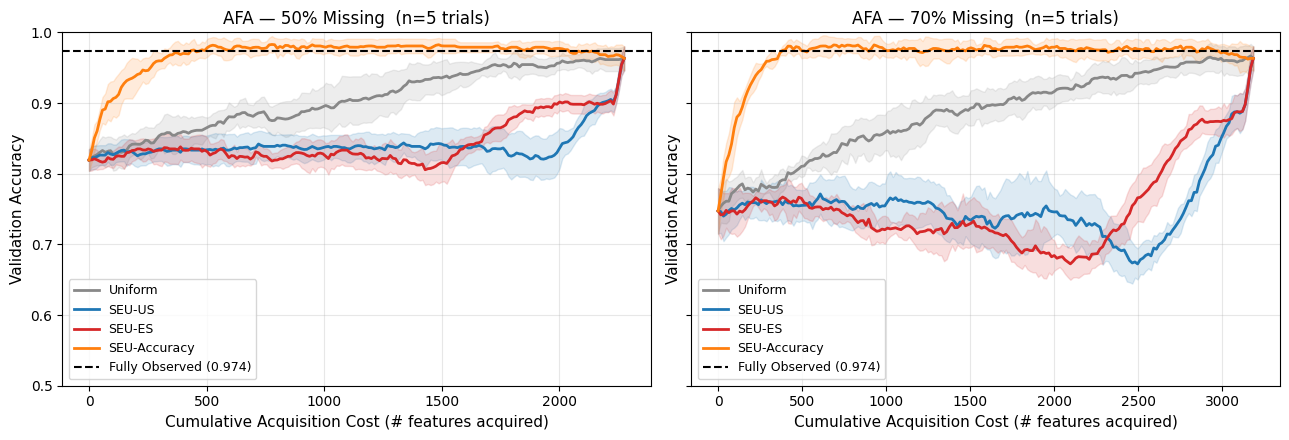

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, mr in zip(axes, MISSING_RATES):
    results = results_by_rate[mr]
    for strategy in STRATEGIES:
        grid, mean_acc, std_acc, *_ = results[strategy]
        ax.plot(grid, mean_acc, label=STRATEGY_LABELS[strategy],
                color=COLORS[strategy], linewidth=2)
        ax.fill_between(grid, mean_acc - std_acc, mean_acc + std_acc,
                        alpha=0.15, color=COLORS[strategy])
    ax.axhline(ceiling_acc, color="black", linestyle="--", linewidth=1.5,
               label=f"Fully Observed ({ceiling_acc:.3f})")
    ax.set_xlabel("Cumulative Acquisition Cost (# features acquired)", fontsize=11)
    ax.set_ylabel("Validation Accuracy", fontsize=11)
    ax.set_title(f"AFA — {int(mr*100)}% Missing  (n={N_TRIALS} trials)", fontsize=12)
    ax.legend(fontsize=9)
    ax.set_ylim(0.5, 1.0)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RESULT_PREFIX}_learning_curves.png", dpi=150)
plt.show()

## Plot 2 — AUC Bar Chart

NameError: name 'RESULT_PREFIX' is not defined

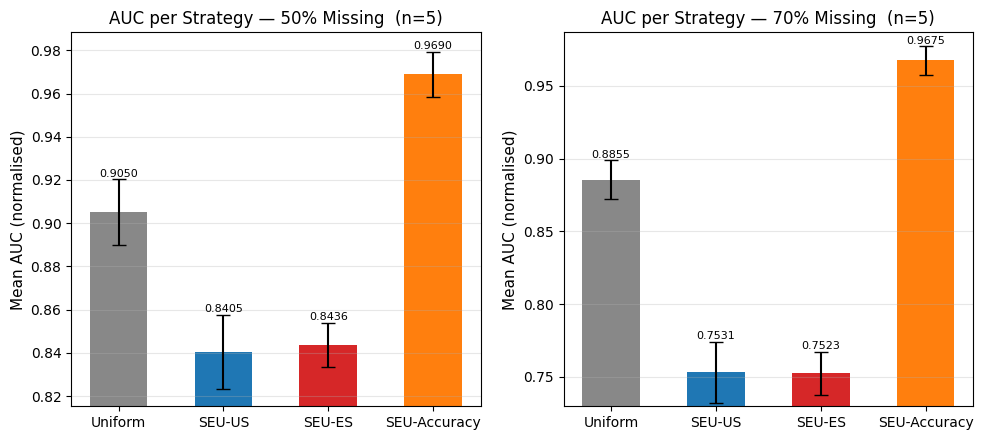

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
x = np.arange(len(STRATEGIES))
width = 0.55

for ax, mr in zip(axes, MISSING_RATES):
    results = results_by_rate[mr]
    means = [results[s][3] for s in STRATEGIES]
    stds  = [results[s][4] for s in STRATEGIES]
    bars = ax.bar(x, means, width, yerr=stds, capsize=5,
                  color=[COLORS[s] for s in STRATEGIES],
                  error_kw={"elinewidth": 1.5})
    ax.set_xticks(x)
    ax.set_xticklabels([STRATEGY_LABELS[s] for s in STRATEGIES], fontsize=10)
    ax.set_ylabel("Mean AUC (normalised)", fontsize=11)
    ax.set_title(f"AUC per Strategy — {int(mr*100)}% Missing  (n={N_TRIALS})", fontsize=12)
    ax.set_ylim(min(means) * 0.97, max(means) * 1.02)
    ax.grid(True, axis="y", alpha=0.3)
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + s + 0.0003,
                f"{m:.4f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(f"{RESULT_PREFIX}_auc_bars.png", dpi=150)
plt.show()

## Plot 3 — Early-Stage Detail (first 50% budget)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, mr in zip(axes, MISSING_RATES):
    results = results_by_rate[mr]
    total_cost = int(X_full.shape[0] * X_full.shape[1] * mr)
    cutoff = int(0.5 * total_cost)
    for strategy in STRATEGIES:
        grid, mean_acc, std_acc, *_ = results[strategy]
        m = grid <= cutoff
        ax.plot(grid[m], mean_acc[m], label=STRATEGY_LABELS[strategy],
                color=COLORS[strategy], linewidth=2)
        ax.fill_between(grid[m], (mean_acc - std_acc)[m], (mean_acc + std_acc)[m],
                        alpha=0.15, color=COLORS[strategy])
    ax.axhline(ceiling_acc, color="black", linestyle="--", linewidth=1.5,
               label=f"Fully Observed ({ceiling_acc:.3f})")
    ax.set_xlabel("Cumulative Acquisition Cost", fontsize=11)
    ax.set_ylabel("Validation Accuracy", fontsize=11)
    ax.set_title(f"Early Stage — {int(mr*100)}% Missing (first 50% budget)", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RESULT_PREFIX}_early_stage.png", dpi=150)
plt.show()

## Summary Table — Accuracy at Budget Fractions + AUC

In [ ]:
import pandas as pd

checkpoints = [0.25, 0.50, 0.75, 1.0]

for mr in MISSING_RATES:
    total_cost = int(X_full.shape[0] * X_full.shape[1] * mr)
    rows = []
    for strategy in STRATEGIES:
        grid, mean_acc, std_acc, mean_auc, std_auc = results_by_rate[mr][strategy]
        row = {"Strategy": STRATEGY_LABELS[strategy]}
        for cp in checkpoints:
            a = np.interp(cp * total_cost, grid, mean_acc)
            row[f"@{int(cp*100)}%"] = f"{a:.4f}"
        row["AUC (mean±std)"] = f"{mean_auc:.4f} ± {std_auc:.4f}"
        rows.append(row)

    summary = pd.DataFrame(rows).set_index("Strategy")
    print(f"\n{'='*60}")
    print(f"Missing rate: {int(mr*100)}%   |   Fully observed ceiling: {ceiling_acc:.4f}")
    print(summary.to_string())